# **Landmark Transformer model for Character-level hand sign detection**

## Setup

In [ ]:
import torch
import torch.nn as nn
from torch import optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from typing import Tuple, Dict, List
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from sklearn.model_selection import train_test_split
import cv2
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

sys.path.insert(0, '..')

In [ ]:
config = {
    'batch_size': 128,
    'num_epochs': 10,
    'learning_rate': 0.0001,
    'dropout_rate': 0.1,
    'd_model': 512,
    'num_heads': 8,
    'encoder_layers': 3,
    'num_classes': 0,  # To be set after loading data
}

In [68]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Data Prep

### Data Exploration

In [ ]:
labels_df = pd.read_csv('../dataset/labels.csv')
# labels_df = pd.read_parquet('../dataset/labels_with_landmarks.parquet')

In [70]:
# labels_df_0.shape, labels_df.shape

In [71]:
labels_df.head(3)

,image,label
0,asl-0-augmented-0.jpg,del
1,asl-0-augmented-1.jpg,del
2,asl-0-augmented-2.jpg,del


In [72]:
labels_df['label'].nunique()

39

In [73]:
config['num_classes'] = labels_df['label'].nunique()

In [74]:
labels_df['label'].value_counts()

label
v          3456
d          3440
z          3432
u          3332
l          3324
o          3316
t          3312
y          3220
s          3208
a          3204
k          3112
x          3112
q          3092
j          3084
f          3072
p          3056
e          3044
i          2996
r          2992
2          2980
3          2960
n          2960
c          2952
g          2940
w          2864
m          2780
7          2696
0          2668
8          2644
4          2592
b          2552
5          2552
h          2552
9          2516
1          2452
6          2436
nothing     120
space       120
del         120
Name: count, dtype: int64

### Integrating Mediapipe landmark detection

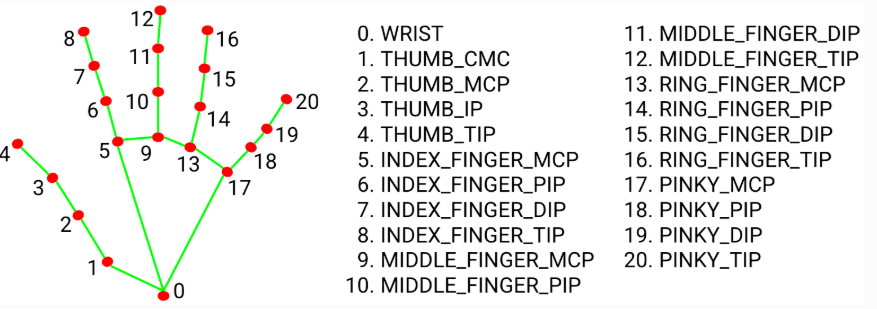

- Preprocessing: Wrist-Centric Normalization & Scale Invariance

In [75]:
def normalize_landmarks(landmarks):
    # landmarks shape: (21, 3)
    wrist = landmarks[0]
    
    # Wrist centering
    centered = landmarks - wrist
    
    # Scale normalization
    # Calculate Euclidean distance for all points from the new origin
    distances = np.linalg.norm(centered, axis=1)
    max_dist = np.max(distances)
    
    # Avoid division by zero
    if max_dist == 0:
        return centered
        
    normalized = centered / max_dist
    return normalized

Landmarks detected!
<class 'mediapipe.tasks.python.components.containers.landmark.NormalizedLandmark'>
NormalizedLandmark(x=0.3998647630214691, y=0.3238876163959503, z=1.9731791667254583e-07, visibility=None, presence=None, name=None)
21


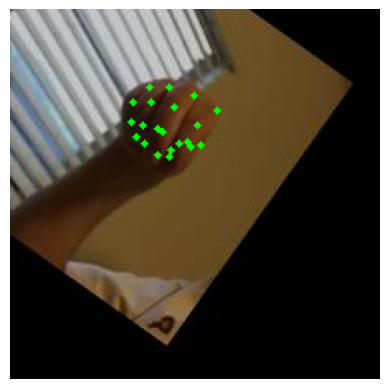

Original landmarks: [[ 3.99864763e-01  3.23887616e-01  1.97317917e-07]
 [ 4.78714228e-01  3.58148485e-01 -4.60653529e-02]
 [ 5.13942540e-01  3.66214484e-01 -8.83370042e-02]
 [ 4.88233775e-01  3.73510182e-01 -1.27053440e-01]
 [ 4.33349371e-01  3.83918643e-01 -1.65612340e-01]
 [ 5.58426619e-01  2.72547245e-01 -9.42052305e-02]
 [ 5.05591989e-01  3.15575391e-01 -1.48431167e-01]
 [ 4.57452506e-01  3.63283783e-01 -1.83742285e-01]
 [ 4.29104179e-01  4.00077075e-01 -2.06400946e-01]
 [ 4.97594774e-01  2.33903974e-01 -9.93330702e-02]
 [ 4.43622947e-01  2.63792545e-01 -1.54477924e-01]
 [ 4.10894930e-01  3.33772182e-01 -1.71550065e-01]
 [ 3.98604751e-01  3.93537641e-01 -1.81175396e-01]
 [ 4.32339728e-01  2.13382453e-01 -1.06809497e-01]
 [ 3.80496085e-01  2.53760248e-01 -1.56143084e-01]
 [ 3.61418337e-01  3.16728950e-01 -1.55336350e-01]
 [ 3.62686515e-01  3.65757227e-01 -1.48630917e-01]
 [ 3.76308382e-01  2.10410774e-01 -1.18687660e-01]
 [ 3.33444595e-01  2.53323257e-01 -1.45736933e-01]
 [ 3.299672

In [76]:
# try using mediapipe to extract landmarks from an image and test the normalization function
landmarker_path = '../hand_landmarker/hand_landmarker.task'
base_options = python.BaseOptions(model_asset_path=landmarker_path)
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
detector = vision.HandLandmarker.create_from_options(options)

image_path = '../dataset/images/' + labels_df['image'].iloc[2000]
img = mp.Image.create_from_file(image_path)
results = detector.detect(img)
landmarks = []
if results.hand_landmarks:
    print("Landmarks detected!")
    print(type(results.hand_landmarks[0][0]))
    print(results.hand_landmarks[0][0])
    print(len(results.hand_landmarks[0]))

    for lm in results.hand_landmarks[0]:
        # print(lm.x, lm.y, lm.z)
        landmarks.append([lm.x, lm.y, lm.z])

    # visualize the landmarks
    img_cv = cv2.imread(image_path)
    for lm in results.hand_landmarks[0]:
        x = int(lm.x * img_cv.shape[1])
        y = int(lm.y * img_cv.shape[0])
        cv2.circle(img_cv, (x, y), 2, (0, 255, 0), -1)
    plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

landmarks = np.array(landmarks)
print("Original landmarks:", landmarks)
normalized_landmarks = normalize_landmarks(landmarks)
print("Normalized landmarks:", normalized_landmarks)

In [77]:
classes = labels_df['label'].unique()
label_map = {label: idx for idx, label in enumerate(classes)}
inverse_label_map = {idx: label for label, idx in label_map.items()}
print("Label map:", label_map)
print("Inverse label map:", inverse_label_map)

Label map: {'del': 0, 'nothing': 1, 'space': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'g': 9, 'h': 10, 'i': 11, 'j': 12, 'k': 13, 'l': 14, 'm': 15, 'n': 16, 'o': 17, 'p': 18, 'q': 19, 'r': 20, 's': 21, 't': 22, 'u': 23, 'v': 24, 'w': 25, 'x': 26, 'y': 27, 'z': 28, '0': 29, '1': 30, '2': 31, '3': 32, '4': 33, '5': 34, '6': 35, '7': 36, '8': 37, '9': 38}
Inverse label map: {0: 'del', 1: 'nothing', 2: 'space', 3: 'a', 4: 'b', 5: 'c', 6: 'd', 7: 'e', 8: 'f', 9: 'g', 10: 'h', 11: 'i', 12: 'j', 13: 'k', 14: 'l', 15: 'm', 16: 'n', 17: 'o', 18: 'p', 19: 'q', 20: 'r', 21: 's', 22: 't', 23: 'u', 24: 'v', 25: 'w', 26: 'x', 27: 'y', 28: 'z', 29: '0', 30: '1', 31: '2', 32: '3', 33: '4', 34: '5', 35: '6', 36: '7', 37: '8', 38: '9'}


In [78]:
class LandmarkDataset(Dataset):
    def __init__(self, labels_df, img_dir, detector, label_map):
        self.labels_df = labels_df
        self.img_dir = img_dir
        self.detector = detector
        self.label_map = label_map

    def __len__(self):
        return len(self.labels_df)
    
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = f"{self.img_dir}/{row['image']}"
        label = row['label']
        label_idx = self.label_map[label]
        label_idx = torch.tensor(label_idx, dtype=torch.long)
        
        # Load image and extract landmarks
        try:
            image = mp.Image.create_from_file(img_path)
            results = self.detector.detect(image)
        except Exception as e:
            print(f"Error occurred while processing image {img_path}: {e}")
            return torch.zeros((21, 3), dtype=torch.float32), label_idx

        if results.hand_landmarks:
            landmarks = []
            for lm in results.hand_landmarks[0]:
                landmarks.append([lm.x, lm.y, lm.z])
            landmarks = np.array(landmarks)
            normalized_landmarks = normalize_landmarks(landmarks)
            return torch.tensor(normalized_landmarks, dtype=torch.float32), label_idx
        else:
            # If no hand detected, return zeros
            return torch.zeros((21, 3), dtype=torch.float32), label_idx

In [79]:
class LandmarkDatasetWithLandmarks(Dataset):
    def __init__(self, labels_df, label_map):
        self.labels_df = labels_df
        self.label_map = label_map

    def __len__(self):
        return len(self.labels_df)
    
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        label = row['label']
        label_idx = self.label_map[label]
        label_idx = torch.tensor(label_idx, dtype=torch.long)

        landmarks = row['landmarks']
        landmarks = np.array(landmarks)
        return torch.tensor(landmarks, dtype=torch.float32), label_idx

In [ ]:
"""
Train Val Test split
70 15 15 split
"""
# Shuffle the DataFrame before splitting
train_df, temp_df = train_test_split(
    labels_df, 
    test_size=0.3, 
    random_state=42, 
    stratify=labels_df['label'] 
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

train_dataset = LandmarkDataset(train_df, '../dataset/images', detector, label_map)
val_dataset = LandmarkDataset(val_df, '../dataset/images', detector, label_map)
test_dataset = LandmarkDataset(test_df, '../dataset/images', detector, label_map)

# train_dataset = LandmarkDatasetWithLandmarks(train_df, label_map)
# val_dataset = LandmarkDatasetWithLandmarks(val_df, label_map)          
# test_dataset = LandmarkDatasetWithLandmarks(test_df, label_map)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [81]:
# Example usage:
for landmarks, label in train_loader:
    print("Landmarks batch shape:", landmarks.shape)  # Should be (batch_size, 21, 3)
    print("Landmarks batch type:", landmarks.dtype)  # Should be torch.float32
    print("Labels batch shape:", label.shape)        # Should be (batch_size,)
    print("Labels batch type:", label.dtype)        # Should be torch.long
    break

Landmarks batch shape: torch.Size([32, 21, 3])
Landmarks batch type: torch.float32
Labels batch shape: torch.Size([32])
Labels batch type: torch.int64


## Model Initialization

In [82]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # Shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

In [83]:
class HandLandmarkTransformer(nn.Module):
    def __init__(self, num_classes):
        super(HandLandmarkTransformer, self).__init__()
        self.d_model = config['d_model']
        self.num_classes = num_classes
        self.dropout_rate = config['dropout_rate']
        self.num_heads = config['num_heads']
        self.encoder_layers = config['encoder_layers']

        # Input: (Batch, 21, 3) -> Output: (Batch, 21, d_model)
        self.input_proj = nn.Linear(3, self.d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model=self.d_model)

        # Use built-in Transformer Blocks for cleaner code & Residuals
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=self.num_heads, 
            dim_feedforward=self.d_model*4, 
            dropout=self.dropout_rate, 
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=self.encoder_layers)

        # Classification Head
        self.fc = nn.Linear(self.d_model, self.num_classes)

    def forward(self, x):
        # x: (Batch, 21, 3)
        
        # Project landmarks to embedding space
        x = self.input_proj(x) # (Batch, 21, d_model)
        
        # ADD Positional Encoding so the model knows which joint is which
        x = self.pos_encoder(x)
        
        # Pass through Transformer layers
        # This allows landmarks to "attend" to each other
        x = self.transformer_encoder(x) # (Batch, 21, d_model)
        
        # Global Average Pooling: Average the "meaning" of all 21 joints
        x = x.mean(dim=1) # (Batch, d_model)
        
        # Final Classification
        return self.fc(x)

In [84]:
from torchinfo import summary

model = HandLandmarkTransformer(num_classes=config['num_classes'])
summary(model, input_size=(config['batch_size'], 21, 3))

Layer (type:depth-idx)                        Output Shape              Param #
HandLandmarkTransformer                       [32, 39]                  --
├─Linear: 1-1                                 [32, 21, 512]             2,048
├─PositionalEncoding: 1-2                     [32, 21, 512]             --
├─TransformerEncoder: 1-3                     [32, 21, 512]             --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [32, 21, 512]             3,152,384
│    │    └─TransformerEncoderLayer: 3-2      [32, 21, 512]             3,152,384
│    │    └─TransformerEncoderLayer: 3-3      [32, 21, 512]             3,152,384
├─Linear: 1-4                                 [32, 39]                  20,007
Total params: 9,479,207
Trainable params: 9,479,207
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 202.47
Input size (MB): 0.01
Forward/backward pass size (MB): 60.57
Params size (MB): 25.31
Estimated Tota

## Model Training

In [85]:
weights = [1.0] * config['num_classes']  # Start with equal weights
# First 3 classes are underrepresented, so give them higher weights
weights[:3] = [20.0] * 3
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

In [86]:
classes

array(['del', 'nothing', 'space', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h',
       'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u',
       'v', 'w', 'x', 'y', 'z', '0', '1', '2', '3', '4', '5', '6', '7',
       '8', '9'], dtype=object)

In [87]:
class TransformerTrainer:
    """Trainer for Transformer model."""
    
    def __init__(
        self,
        model: nn.Module,
        device: str = 'cuda' if torch.cuda.is_available() else 'cpu',
        learning_rate: float = 1e-4,
        weight_decay: float = 0.0,
        weights_tensor: torch.Tensor = None,
        # inverse_label_map: Dict[int, str] = None
    ):
        """
        Initialize trainer.
        
        Args:
            model: Transformer model
            device: Device to train on
            learning_rate: Learning rate
            weight_decay: Weight decay for regularization
        """
        self.model = model.to(device)
        self.device = device
        self.optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.2, patience=3
        )
        if weights_tensor is not None:
            self.criterion = nn.CrossEntropyLoss(weight=weights_tensor)
        else:
            self.criterion = nn.CrossEntropyLoss()
        self.inverse_label_map = inverse_label_map
        
        print(f"Initialized trainer on device: {device}")
    
    def train_epoch(self, train_loader: DataLoader) -> float:
        """
        Train for one epoch.
        
        Args:
            train_loader: Training data loader
            
        Returns:
            Average training loss
        """
        self.model.train()
        total_loss = 0.0
        
        for landmarks, labels in tqdm(train_loader, desc="Training", leave=False):
            # Get batch data
            encoder_input = landmarks.to(self.device)
            # targets = torch.tensor([self.inverse_label_map[l.item()] for l in labels], dtype=torch.long).to(self.device)
            targets = labels.to(self.device)

            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(encoder_input)
            
            # Calculate loss
            loss = self.criterion(outputs, targets)
            
            # Backward pass
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(train_loader)
    
    def evaluate(self, val_loader: DataLoader) -> Tuple[float, np.ndarray, np.ndarray]:
        """
        Evaluate model on validation/test set.
        
        Args:
            val_loader: Validation data loader
            
        Returns:
            Tuple of (average loss, predictions, true values)
        """
        self.model.eval()
        total_loss = 0.0
        all_predictions = []
        all_targets = []
        
        with torch.no_grad():
            for landmarks, labels in tqdm(val_loader, desc="Evaluating", leave=False):
                encoder_input = landmarks.to(self.device)
                # targets = torch.tensor([self.inverse_label_map[l.item()] for l in labels], dtype=torch.long).to(self.device)
                targets = labels.to(self.device)

                outputs = self.model(encoder_input)
                
                loss = self.criterion(outputs, targets)
                total_loss += loss.item()
                
                all_predictions.append(outputs.cpu().numpy())
                all_targets.append(targets.cpu().numpy())
        
        predictions = np.concatenate(all_predictions, axis=0)
        true_values = np.concatenate(all_targets, axis=0)
        
        return total_loss / len(val_loader), predictions, true_values
    
    def fit(
        self,
        train_loader: DataLoader,
        val_loader: DataLoader,
        epochs: int = 50,
        early_stopping_patience: int = 10,
        save_path: str = None
    ) -> Dict[str, List[float]]:
        """
        Train the model.
        
        Args:
            train_loader: Training data loader
            val_loader: Validation data loader
            epochs: Number of epochs
            early_stopping_patience: Patience for early stopping
            save_path: Path to save best model
            
        Returns:
            Dictionary with training history
        """
        history = {
            'train_loss': [],
            'val_loss': []
        }
        
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")
            
            # Train
            train_loss = self.train_epoch(train_loader)
            history['train_loss'].append(train_loss)
            
            # Validate
            val_loss, _, _ = self.evaluate(val_loader)
            history['val_loss'].append(val_loss)
            
            # Update learning rate
            self.scheduler.step(val_loss)
            
            print(f"Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Learning Rate: {self.optimizer.param_groups[0]['lr']}")
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                
                if save_path:
                    torch.save(self.model.state_dict(), save_path)
                    print(f"Saved best model to {save_path}")
            else:
                patience_counter += 1
                
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping triggered after {epoch + 1} epochs")
                break
        
        # Load best model
        if save_path:
            self.model.load_state_dict(torch.load(save_path))
            print("Loaded best model")
        
        return history
    
    def predict(self, test_loader: DataLoader) -> np.ndarray:
        """
        Make predictions on test set.
        
        Args:
            test_loader: Test data loader
            
        Returns:
            Predictions array
        """
        _, predictions, _ = self.evaluate(test_loader)
        return predictions

In [88]:
for landmarks, labels in tqdm(train_loader, desc="Training", leave=False):
    # targets = torch.tensor([inverse_label_map[l.item()] for l in labels], dtype=torch.long).to(self.device)
    for l in labels:
        label_index = l.item() 
        
        # Now you can use it to look up the original character in your inverse map
        # Note: Use idx_to_label here if you want to see 'a', 'b', etc.
        print(f"Index: {label_index}")
        print(f"Character: {inverse_label_map[label_index]}") 
        break
    break

Index: 23
Character: u


In [91]:
checkpoint_path = '../checkpoints/best_model.pth'

model = HandLandmarkTransformer(num_classes=config['num_classes'])
trainer = TransformerTrainer(model=model, device=device, learning_rate=config['learning_rate'], weights_tensor=weights_tensor)

Initialized trainer on device: cuda


In [92]:
history = trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=config['num_epochs'],
    early_stopping_patience=10,
    save_path=checkpoint_path
)


Epoch 1/10


Train Loss: 2.253008, Val Loss: 1.745360, Learning Rate: 0.0001
Saved best model to ../checkpoints/best_model.pth

Epoch 2/10


Train Loss: 1.735978, Val Loss: 1.735777, Learning Rate: 0.0001
Saved best model to ../checkpoints/best_model.pth

Epoch 3/10


Train Loss: 1.692115, Val Loss: 1.644929, Learning Rate: 0.0001
Saved best model to ../checkpoints/best_model.pth

Epoch 4/10


Train Loss: 1.661465, Val Loss: 1.633418, Learning Rate: 0.0001
Saved best model to ../checkpoints/best_model.pth

Epoch 5/10


...

Train Loss: 1.634981, Val Loss: 1.648038, Learning Rate: 0.0001

Epoch 7/10


Train Loss: 1.623364, Val Loss: 1.630702, Learning Rate: 0.0001

Epoch 8/10


Train Loss: 1.608964, Val Loss: 1.612324, Learning Rate: 0.0001
Saved best model to ../checkpoints/best_model.pth

Epoch 9/10


Train Loss: 1.604478, Val Loss: 1.612760, Learning Rate: 0.0001

Epoch 10/10


Train Loss: 1.599124, Val Loss: 1.633153, Learning Rate: 0.0001
Loaded best model


In [93]:
def plot_loss(history, save_path):
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Hand Landmark Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (CrossEntropy)')
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path)
    plt.show()

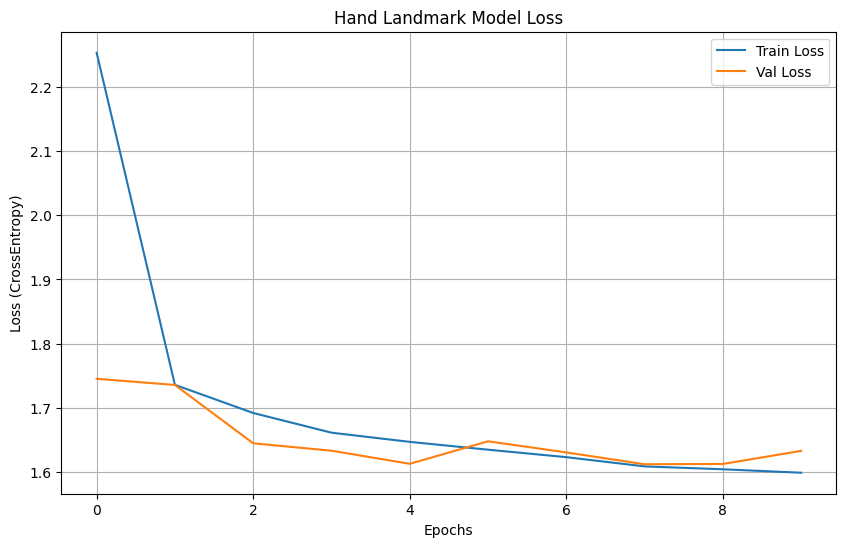

In [95]:
plot_loss(history, save_path='../results/transformer_loss.png')

## Model Inference

In [96]:
# Load best model for evaluation
model = HandLandmarkTransformer(num_classes=config['num_classes'])
model.load_state_dict(torch.load(checkpoint_path))
model.to(device)
loss, predictions, true_values = trainer.evaluate(test_loader)

In [97]:
print(f"Test Loss: {loss:.6f}")

Test Loss: 1.661448


In [101]:
# 1. Convert logits to class indices
# predictions shape: (N, 39) -> pred_indices shape: (N,)
pred_indices = np.argmax(predictions, axis=1)

# 2. Calculate simple accuracy
correct_predictions = np.sum(pred_indices == true_values)
total_samples = len(true_values)
accuracy = correct_predictions / total_samples

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Correct: {correct_predictions} / {total_samples}")

Test Accuracy: 56.37%
Correct: 9069 / 16089


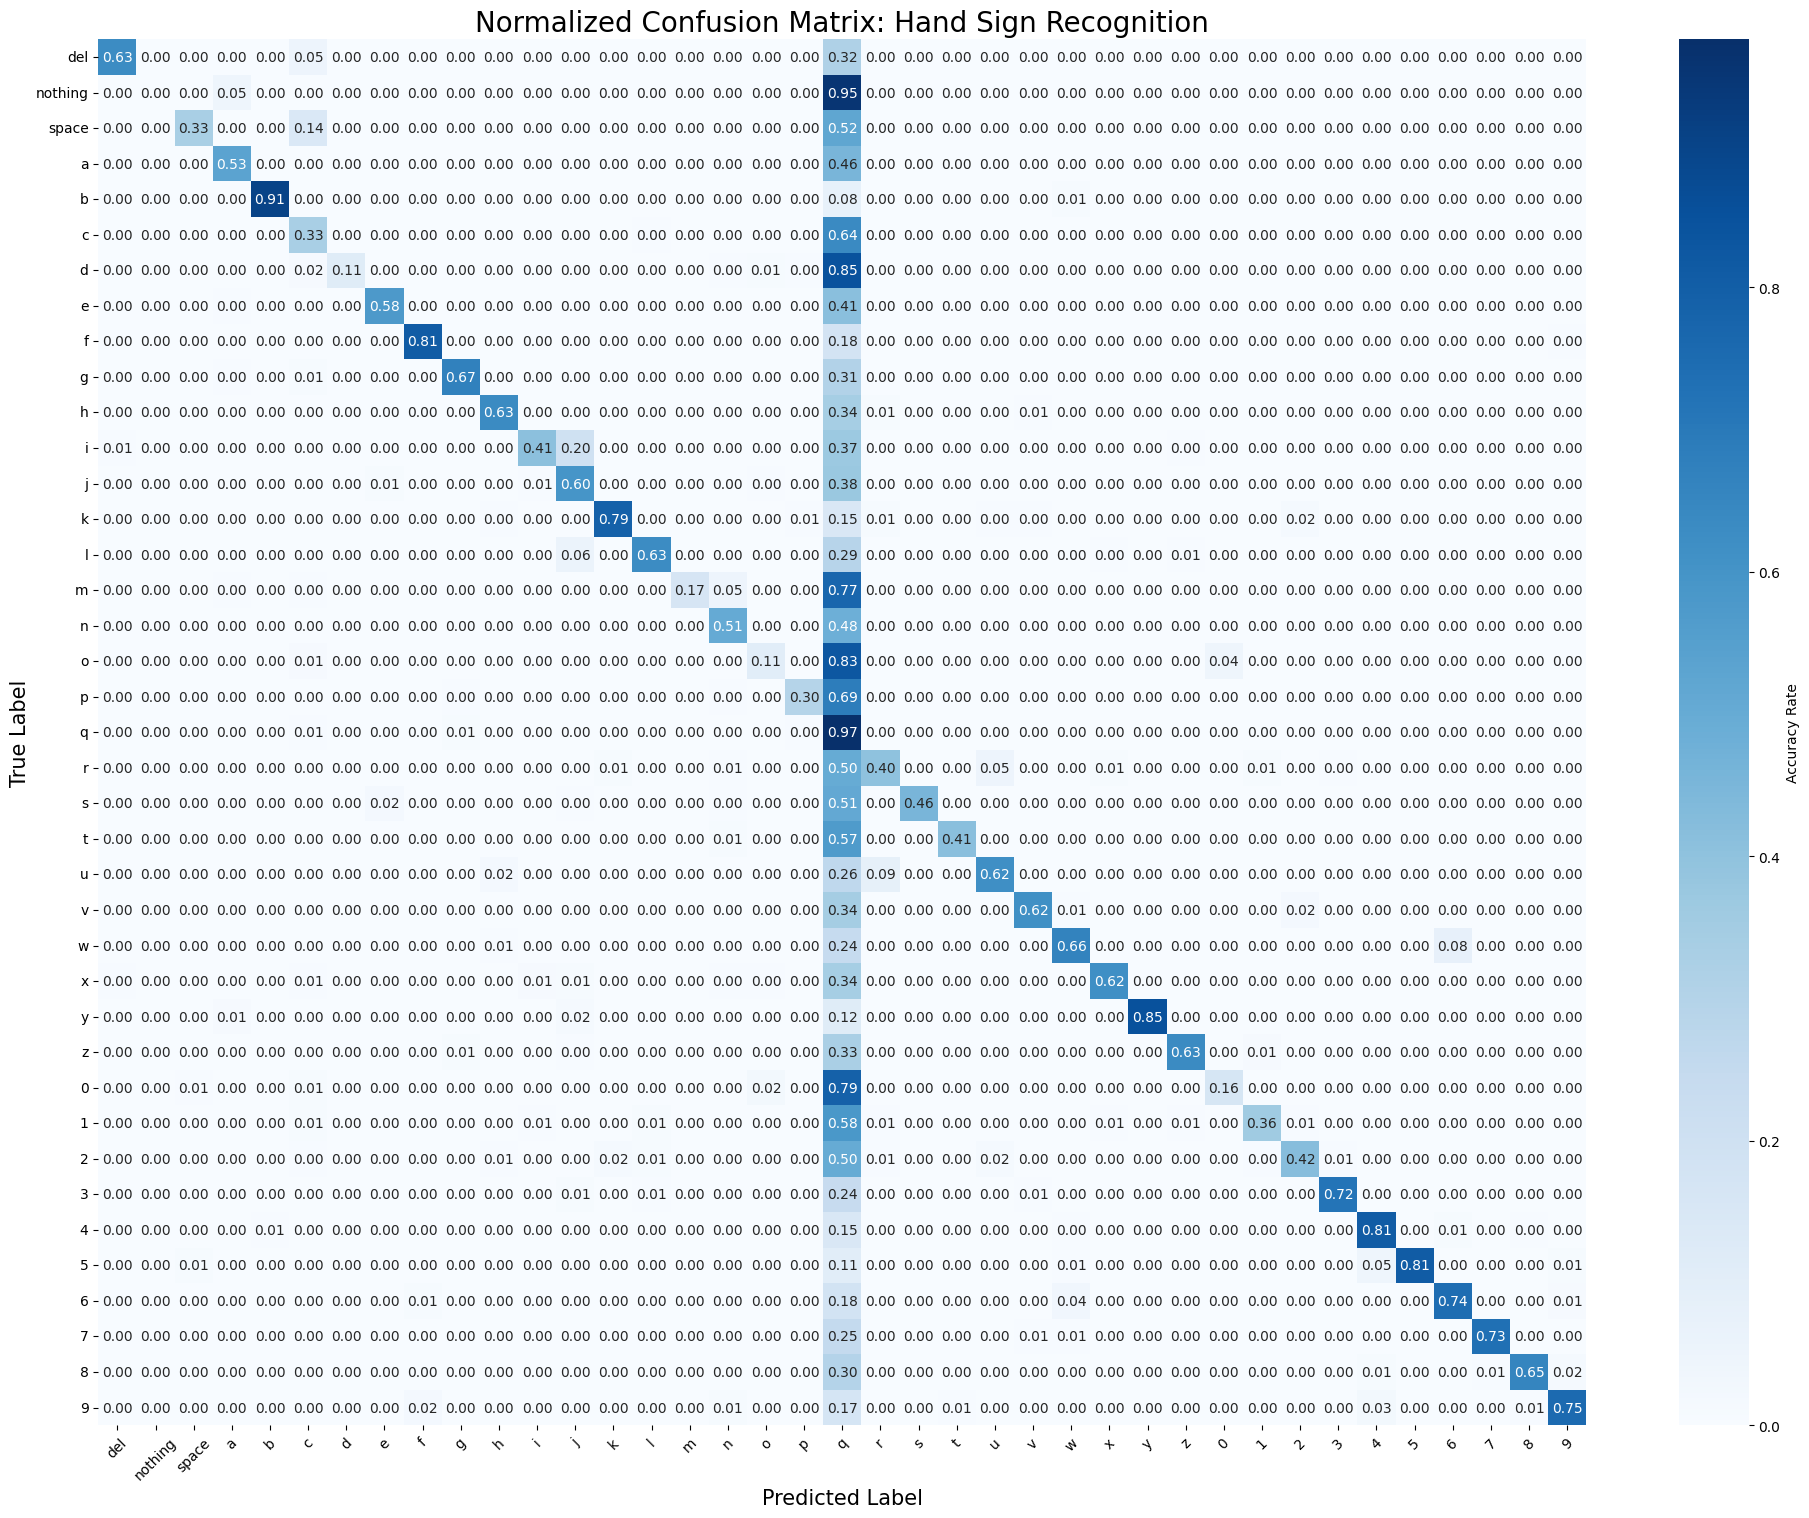

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_styled_confusion_matrix(true_values, predictions, label_map):
    # 1. Convert logits to class indices
    pred_indices = np.argmax(predictions, axis=1)
    
    # 2. Get the list of names in the correct order
    # label_map keys are usually '0', '1', ... 'A', 'B', ... 'space'
    class_names = list(label_map.keys())
    
    # 3. Compute normalized confusion matrix
    # 'true' normalization shows the % of correct hits per class
    cm = confusion_matrix(true_values, pred_indices, normalize='true')
    
    # 4. Plotting
    plt.figure(figsize=(24, 18)) # Big enough for 39 classes
    sns.heatmap(
        cm, 
        annot=True, # Set to True if you want the numbers, but it's messy with 39 classes
        fmt='.2f', 
        cmap='Blues', # Or 'Purples' to match your reference
        xticklabels=class_names, 
        yticklabels=class_names,
        cbar_kws={'label': 'Accuracy Rate'}
    )
    
    plt.title('Normalized Confusion Matrix: Hand Sign Recognition', fontsize=20)
    plt.xlabel('Predicted Label', fontsize=15)
    plt.ylabel('True Label', fontsize=15)
    plt.xticks(rotation=45)
    plt.show()

# Call the function
plot_styled_confusion_matrix(true_values, predictions, label_map)